In [2]:
import pandas as pd
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import scipy.signal as signal
import pickle
import os

In [5]:
file_folder = './dataFolder/TrackingData_2022_11_10/ErrorAngle/MSCoherence/'
coherence_files = glob.glob(file_folder + '*MV*')

In [8]:
def MutualInfo_Coherence(mscohere):
    mscoher = np.asarray(mscohere)
    return -np.log2(1 - mscoher)

In [80]:
all_MI = []
all_MI_band = []
for file in coherence_files:
    
    try:
        mscoherence = pd.DataFrame(pd.read_pickle(file))
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
        
    mothID = '_'.join(file.split('\\')[-1][:-4].split('_')[1:])
    nect_body = mscoherence['nectary_body']
    nect_pilifer = mscoherence['nectary_pilifer']
    pilifer_body = mscoherence['pilifer_body']
    
    freqs = mscoherence['frequency']
    df = freqs[2] - freqs[1] 
    fmin = freqs[1]
    fmax = 20
    band = (freqs >= fmin) & (freqs <= fmax)
    
    MI = {}
    MI_band = {}
    print(f"the MI in the range of {fmin} to {fmax} in {mothID} is")
    for val, name in zip([nect_body, nect_pilifer, pilifer_body], ['nect_body', 'nect_pilifer', 'pilifer_body']):
        MI[name] = MutualInfo_Coherence(val.values)
        MI_band[name] = np.sum(MI[f"{name}"][band]) * df
        print(f'{name} : {MI_band[name]}')
    MI['mothID'] = len(val.values)*[mothID]
    MI_band['mothID'] = mothID
    
    MI_df = pd.DataFrame(MI)
    all_MI.append(MI_df)
    MI_band_df = pd.DataFrame(MI_band, index = [0])
    all_MI_band.append(MI_band_df)

the MI in the range of 0.390625 to 20 in MV_m11_130802 is
nect_body : 33.59999662365507
nect_pilifer : 10.504153358960423
pilifer_body : 10.924247391626213
the MI in the range of 0.390625 to 20 in MV_m13_130802 is
nect_body : 33.85637308785128
nect_pilifer : 7.9809530475694475
pilifer_body : 11.765243061666553
the MI in the range of 0.390625 to 20 in MV_m14_130806 is
nect_body : 27.843324450564783
nect_pilifer : 8.216758718712097
pilifer_body : 9.228802435958578
the MI in the range of 0.390625 to 20 in MV_m1_130802 is
nect_body : 28.66823778467122
nect_pilifer : 8.315071629969697
pilifer_body : 7.622323115905391
the MI in the range of 0.390625 to 20 in MV_m4_130802 is
nect_body : 31.23163843023956
nect_pilifer : 16.382705597252496
pilifer_body : 13.112893344219723
the MI in the range of 0.390625 to 20 in MV_m5_130802 is
nect_body : nan
nect_pilifer : nan
pilifer_body : nan
the MI in the range of 0.390625 to 20 in MV_m8_130805 is
nect_body : 30.72179565105802
nect_pilifer : 12.130833258

In [84]:
df = pd.concat(all_MI_band)
df

,nect_body,nect_pilifer,pilifer_body,mothID
0,33.599997,10.504153,10.924247,MV_m11_130802
0,33.856373,7.980953,11.765243,MV_m13_130802
0,27.843324,8.216759,9.228802,MV_m14_130806
0,28.668238,8.315072,7.622323,MV_m1_130802
0,31.231638,16.382706,13.112893,MV_m4_130802
0,NaN,NaN,NaN,MV_m5_130802
0,30.721796,12.130833,12.788316,MV_m8_130805
0,26.565499,5.431871,8.119632,MV_m9_130801


In [86]:
df_long = df.melt(
    id_vars='mothID',
    value_vars=['nect_body', 'nect_pilifer', 'pilifer_body'],
    var_name='pair',
    value_name='MI_bits'
)

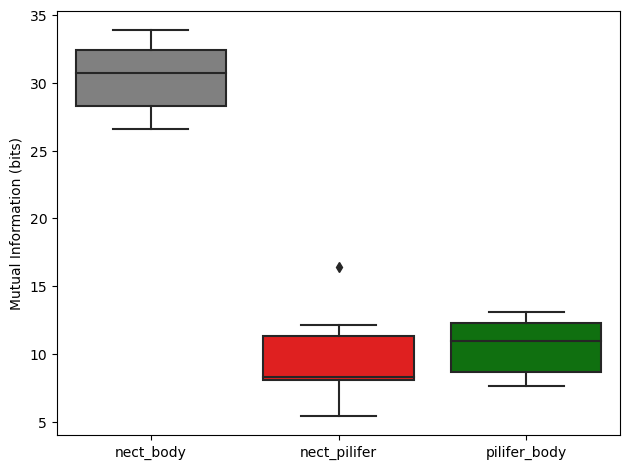

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    'nect_body': 'grey',
    'nect_pilifer': 'red',
    'pilifer_body': 'green'
}

sns.boxplot(
    data=df_long,
    x='pair',
    y='MI_bits',
    palette = palette
)

plt.ylabel('Mutual Information (bits)')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [108]:
all_MI_df = pd.concat(all_MI)
all_MI_df['_t'] = all_MI_df.groupby('mothID').cumcount()
# fft_average['_t'] = fft_average.groupby(fft_average['mothID']).cumcount()
stats = all_MI_df.groupby('_t')[all_MI_df.columns[:3]].agg(['mean', 'std'])

In [109]:
stats

nect_body           nect_pilifer           pilifer_body          
         mean       std         mean       std         mean       std
_t                                                                   
0    4.775151  1.115354     1.475234  1.291117     1.764313  1.631285
1    5.759886  0.943762     1.524682  0.888501     1.637991  0.992271
2    5.781009  1.195058     1.160078  0.595287     1.226670  0.667498
3    5.114038  0.922730     0.670211  0.740033     0.748853  0.796259
4    5.100261  0.876194     0.656556  1.026209     0.641196  1.022747
..        ...       ...          ...       ...          ...       ...
124  0.229577  0.148449     0.405052  0.294829     0.684981  0.800904
125  0.381070  0.433202     0.390637  0.276890     0.641750  0.701543
126  0.296490  0.274139     0.217127  0.155789     0.401575  0.508224
127  0.403948  0.215893     0.360432  0.224105     0.478349  0.397369
128  0.373314  0.756327     0.533107  0.686345     0.437016  0.389580

[129 rows x 6 columns]

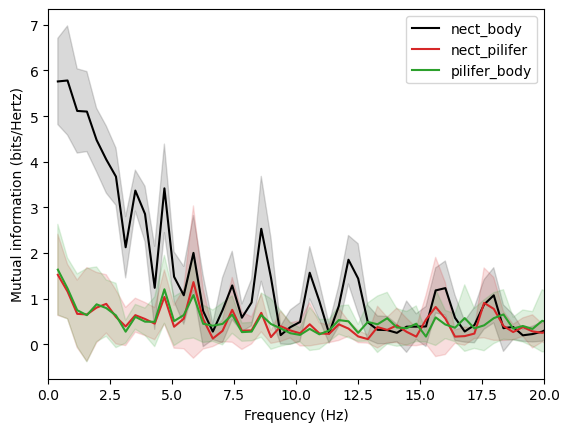

In [113]:
fig = plt.figure()
# ax1 = fig.add_axes([0.1,0.1,0.75,0.9])


cols  = ['nect_body', 'nect_pilifer', 'pilifer_body']  
colors = ['black', 'tab:red', 'tab:green']

stats_sans0 = stats[1:]
freq = freqs[1:]
# Left axis (first two columns)
for col, c in zip(cols, colors):
    m = stats_sans0[(col, 'mean')].values
    s = stats_sans0[(col, 'std')].values
    plt.plot(freq, m, color=c, label=col)
    plt.fill_between(freq, m - s, m + s, color=c, alpha = 0.15)
    plt.xlim(0,20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mutual information (bits/Hertz)')
plt.legend()
fig.savefig('./dataFolder/TrackingData_2022_11_10/ErrorAngle/Plots/all_MI.png')